In [2]:
from matplotlib import pyplot as plt
from mpmath import linspace
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, confusion_matrix
from sklearn.utils import shuffle
from sympy.abc import alpha
from sympy.printing.pretty.pretty_symbology import line_width

In [3]:
def plotData(x1, y1, x2 = None, y2 = None, x3 = None, y3 = None, title = None, xLabel = None, yLabel = None):
    plt.plot(x1, y1, 'ro', label = 'train data')
    if x2 is not None:
        plt.plot(x2, y2, 'b-', label = 'learnt model')
    if x3 is not None:
        plt.plot(x3, y3, 'g^', label = 'test data')
    plt.xlabel(xLabel)
    plt.ylabel(yLabel)
    plt.title(title)
    plt.legend()
    plt.show()

def plotClassifier(x1, x2, y, lineX, lineY, title = None):
    plt.figure(figsize=(10, 6))
    plt.scatter(x1, x2, c=y, cmap='bwr', alpha=0.7, edgecolors='k')
    plt.plot(lineX, lineY, color='red', linewidth=2, label='Decision Boundary')
    plt.title(title)
    plt.legend()
    plt.show()

def plot3Ddata(x1Train, x2Train, yTrain, x1Model = None, x2Model = None, yModel = None, x1Test = None, x2Test = None, yTest = None, title = None, xLabel = None, yLabel = None, zLabel = None):
    fig = plt.figure(figsize=(10, 12))
    ax = fig.add_subplot(projection = '3d')
    if x1Train is not None:
        ax.scatter(x1Train, x2Train, yTrain, c = 'r', marker = 'o', label = 'train data')
    if x1Model is not None:
        ax.plot_surface(x1Model, x2Model, yModel, alpha=0.4, label = 'learnt model')
    if x1Test is not None:
        ax.scatter(x1Test, x2Test, yTest, c = 'g', marker = '^', label = 'test data')
    plt.title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)
    ax.set_zlabel(zLabel)
    ax.legend()
    plt.show()

def plot4Ddata(trainX, testX, trainY, testY, xLabels = None, yLabel = None, title = None):
    fig, axes = plt.subplots(1, len(trainX), figsize=(15,5))
    for i in range(len(trainX)):
        axes[i].scatter(trainX[i], trainY, c='r', marker = 'o', label = 'train data')
        axes[i].scatter(testX[i], testY, c='g', marker='^', label = 'test data')
        axes[i].set_xlabel(xLabels[i])
        axes[i].set_ylabel(yLabel)
        axes[i].legend()
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [4]:
import math

# X - shape (n_samples, n_features)
# y - shape (n_samples, )
class MyScaler:
    def __init__(self):
        self.means = []
        self.stds = []

    # fit(X) - determines means and stds for every feature
    # X - list of lists (n_samples, n_features) | list (n_samples, )
    def fit(self, X):
        self.means = []
        self.stds = []

        if isinstance(X[0], list):
            for j in range(len(X[0])): # for every feature
                Xi = [xi[j] for xi in X] # take all the samples of this feature
                self.means.append(sum(Xi) / len(X[0])) # append the mean of the feature j
                self.stds.append(math.sqrt(sum((x - self.means[-1]) ** 2 for x in Xi) / len(X[0]))) # append the std of the feature j
        else:
            self.means.append(sum(X) / len(X))
            self.stds.append(math.sqrt(sum((x - self.means[-1]) ** 2 for x in X) / len(X)))

    # transform(X) - applies (feature_data - feature_mean) / feature_std for every feature in X
    # X - list of lists (n_samples, n_features) | list (n_samples, )
    def transform(self, X):
        scaledX = []
        for xi in X:
            if isinstance(X[0], list):
                scaledXi = []
                for j in range(len(xi)):
                    std = self.stds[j] if self.stds[j] != 0 else 1.0 # avoid division by zero if std is 0
                    scaledXi.append((xi[j] - self.means[j]) / std)
                scaledX.append(scaledXi)
            else:
                scaledX.append((xi - self.means[0]) / self.stds[0])

        return scaledX

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [5]:
def splitData(inputData, labels, outputData):
    np.random.seed(1)
    indexes = [i for i in range(len(inputData[0]))]
    trainSample = np.random.choice(indexes, int(0.8*len(inputData[0])), replace=False).tolist()
    testSample = [i for i in indexes if not i in trainSample]
    trainInputs = []
    testInputs = []
    trainOutputs = [outputData[i] for i in trainSample]
    testOutputs = [outputData[i] for i in testSample]

    for idx, data in enumerate(inputData):
        trainInputs.append([data[i] for i in trainSample])
        testInputs.append([data[i] for i in testSample])
        if len(inputData) == 1:
            plotData(trainInputs[-1], trainOutputs, [], [], testInputs[-1], testOutputs,
                 title=f'{labels[idx]} vs happiness train and test data',
                 xLabel=labels[0], yLabel=labels[1])

    if len(inputData) == 2:
        plot3Ddata(trainInputs[0], trainInputs[1], trainOutputs, None, None, None, testInputs[0], testInputs[1], testOutputs, 'Train vs Test Data',
                   xLabel= labels[0], yLabel= labels[1], zLabel= labels[2])

    if len(inputData) >= 3:
        plot4Ddata(trainInputs, testInputs, trainOutputs, testOutputs, labels[0], labels[1], 'Train vs Test Data')

    return trainInputs, testInputs, trainOutputs, testOutputs

In [6]:
import random


# Shuffle data
# X - matrix like array with shape (n_samples, n_attributes)
# y - array with shape (n_samples, )
def shuffleNP(X, y):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    return X[indices], y[indices]

# X - list of lists (n_samples, n_attributes)
# y - list (n_samples, )
def shuffle(X, y):
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    shuffledX = [X[i] for i in indices]
    shuffledY = [y[i] for i in indices]
    return shuffledX, shuffledY

class MySGDRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = []

    # X - matrix like array with shape (n_samples, n_attributes)
    # y - array with shape (n_samples, )
    def fit(self, X, y, learningRate = 0.001, noEpoch = 1000):
        # initialize as many coef as n_attributes + 1, because the intercept is stored as coef as well
        self.coef_ = [0.0 for _ in range(len(X[0]) + 1)]
        for epoch in range(noEpoch):
            for i in range(len(X)): # iterate over every sample in the training data
                yiComputed = self.eval(X[i]) # evaluate the sample
                crtError = yiComputed - y[i]
                for j in range(len(X[0])): # update the coefficients
                    self.coef_[j] = self.coef_[j] - learningRate * crtError * X[i][j]
                # update the intercept
                self.coef_[len(X[0])] = self.coef_[len(X[0])] - learningRate * crtError * 1

        self.intercept_ = self.coef_[-1]
        self.coef_ = self.coef_[:-1]

    # X - matrix like array with shape (n_samples, n_attributes)
    # y - array with shape (n_samples, )
    def fit_batch(self, X, y, learningRate = 0.001, noEpoch = 1000):
        self.coef_ = [0.0 for _ in range(len(X[0]) + 1)]
       # self.coef_ = [random.uniform(-0.01, 0.01) for _ in range(len(X[0]) + 1)]
        for epoch in range(noEpoch):
            X, y = shuffle(X, y) # shuffle data at the start of each epoch for better convergence
            gradients = [0.0 for _ in range(len(self.coef_))]
            for i in range(len(X)): # apply gradient descent for every sample in the data
                yiComputed = self.eval(X[i])
                crtError = yiComputed - y[i]
                for j in range(len(X[0])): # update coefficient's gradient
                    gradients[j] += crtError * X[i][j]
                # update intercept gradient
                gradients[-1] += crtError * 1

            for j in range(len(self.coef_)): # update coef only after a whole data compute
                # normalize de gradient to be independent to the batch size
                self.coef_[j] = self.coef_[j] - learningRate * (gradients[j] / len(X))

        self.intercept_ = self.coef_[-1]
        self.coef_ = self.coef_[:-1]

    # Evaluate a particular sample
    # xi - sample i
    def eval(self, xi):
        yi = self.coef_[-1] # initialize yi with the intercept
        for j in range(len(xi)):
            yi += self.coef_[j] * xi[j] # apply the linear formula for the n_attributes of xi
        return yi

    # Compute the whole input
    # X - matrix like array with shape (n_samples, n_attributes)
    def predict(self, X):
        yComputed = [self.eval(xi) for xi in X]
        return yComputed


In [7]:
# computedY, y - list (n_samples, )
def error(computedY, y):
    error = 0.0
    for t1, t2 in zip(computedY, y):
        error += (t1 - t2) ** 2
    error = error / len(testOutputs)
    print(f'MAE (manual): {error:.2f}')

# computedY, y - np.array (n_samples, )
def errorNP(computedTestOutputs, testOutputs):
    error = mean_squared_error(testOutputs, computedTestOutputs)
    print(f'MAE (tool): {error:.2f}')

In [8]:
import pandas as pd
from sklearn.linear_model import SGDRegressor

# Read attributes in dataframes
df = pd.read_csv("2017.csv")
happiness = df['Happiness.Score'].values
gdp = df['Economy..GDP.per.Capita.'].values
freedom = df.Freedom.values

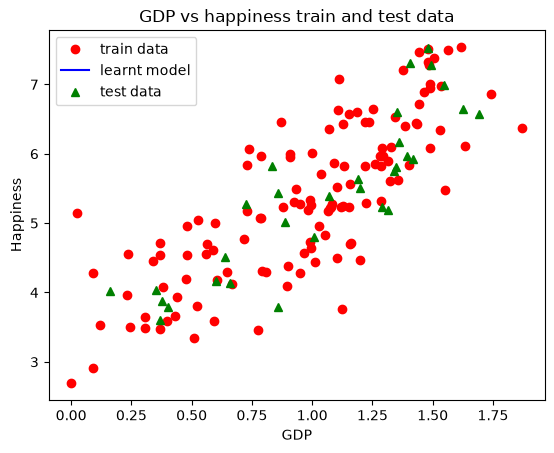

my learnt model: f(x) = 2.3142 + 2.3512  * x
tool learnt model: f(x) = 3.2201 + 2.1344  * x


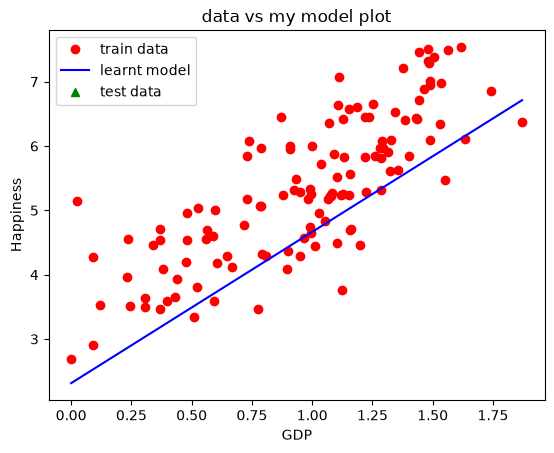

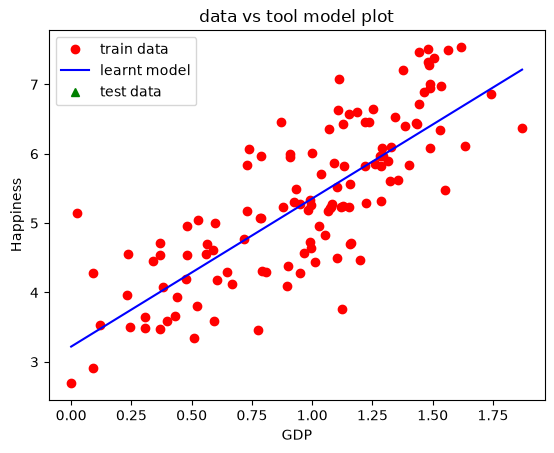

My model error: 
MAE (manual): 0.67
MAE (tool): 0.67
Tool model error: 
MAE (manual): 0.30
MAE (tool): 0.30


In [9]:
# 1st exercise (BGD Regression)
# GDP - input
# Happiness - output
inputData = [[float(x) for x in gdp]]
outputData = [float(x) for x in happiness]

# Initialize regressor
myRegressor = MySGDRegression()
toolRegressor = SGDRegressor(learning_rate='constant', penalty=None)


# Split data => input: array of arrays, output: array
trainInputs, testInputs, trainOutputs, testOutputs = splitData(inputData, ['GDP', 'Happiness'], outputData)
# Prepare data for use
trainInputsT = [[x] for x in trainInputs[0]]
testInputsT = [[x] for x in testInputs[0]]

# Prepare data for tool use
toolTrainInputs = np.array(trainInputsT)
toolTestInputs = np.array(testInputsT)
toolTrainOutputs = np.array(trainOutputs)
toolTestOutputs = np.array(testOutputs)

# Train the regressor
epochCount = 1000
myRegressor.fit_batch(trainInputsT, trainOutputs, noEpoch=epochCount)

for _ in range(epochCount):
    toolTrainInputs, toolTrainOutputs = shuffleNP(toolTrainInputs, toolTrainOutputs)
    toolRegressor.partial_fit(toolTrainInputs, toolTrainOutputs)

# Print the model formula
print(f'my learnt model: f(x) = {myRegressor.intercept_:.4f} + {myRegressor.coef_[0]:.4f}  * x')
print(f'tool learnt model: f(x) = {toolRegressor.intercept_.item():.4f} + {toolRegressor.coef_[0]:.4f}  * x')

# Plot the model
noOfPoints = 50
xRef = linspace(min(trainInputs[0]), max(trainInputs[0]), noOfPoints)
yRef = [myRegressor.intercept_ + myRegressor.coef_[0] * x for x in xRef]
plotData(trainInputs[0], trainOutputs, xRef, yRef, [], [], 'data vs my model plot', yLabel='Happiness', xLabel='GDP')
yRef = [toolRegressor.intercept_ + toolRegressor.coef_[0] * x for x in xRef]
plotData(trainInputs[0], trainOutputs, xRef, yRef, [], [], 'data vs tool model plot', yLabel='Happiness', xLabel='GDP')

# Print test data prediction error
myComputedTestOutputs = myRegressor.predict(testInputsT)
toolComputedTestOutputs = toolRegressor.predict(testInputsT)
print(f"My model error: ")
error(myComputedTestOutputs, testOutputs)
errorNP(myComputedTestOutputs, testOutputs)
print(f"Tool model error: ")
error(toolComputedTestOutputs, testOutputs)
errorNP(toolComputedTestOutputs, testOutputs)

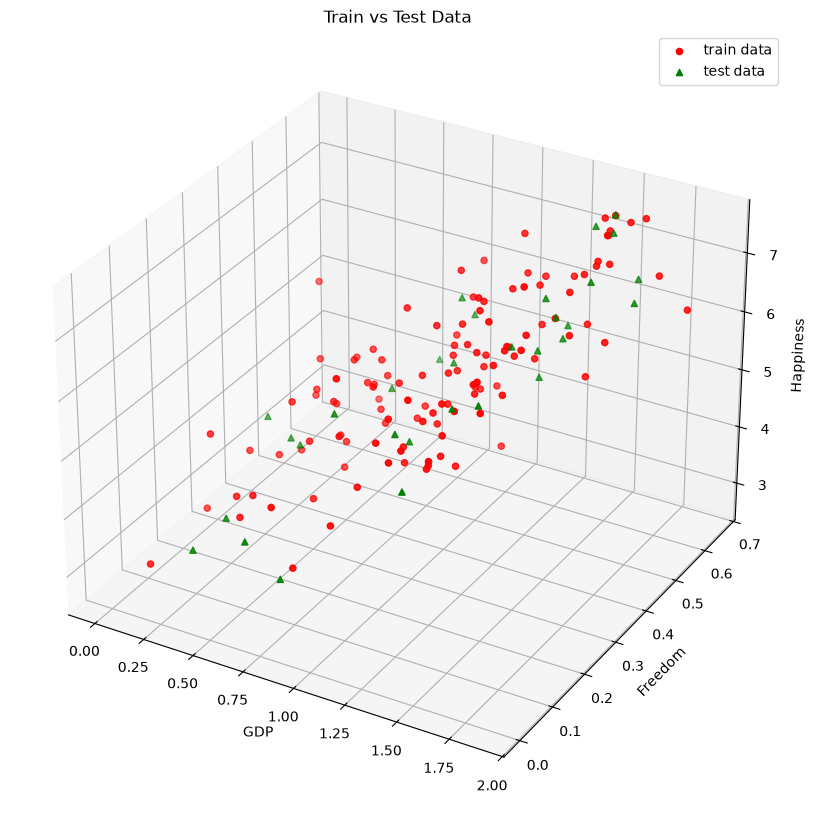

my learnt model: f(x) = 2.1789 + 2.2185  * x1 + 0.9401 * x2
tool learnt model: f(x) = 2.4363 + 1.8575  * x + 2.6237 * x2


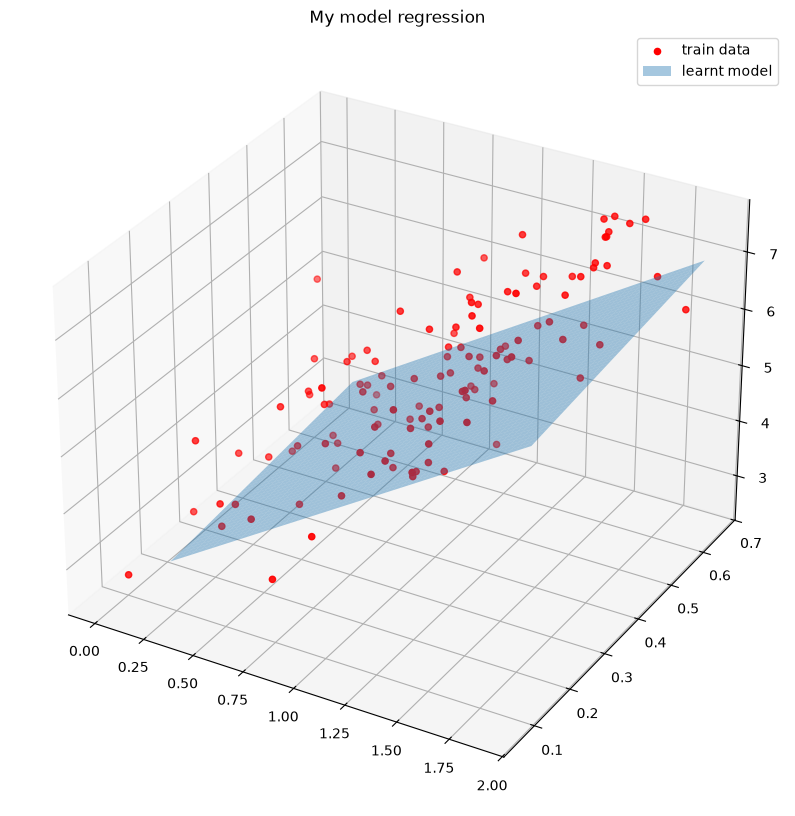

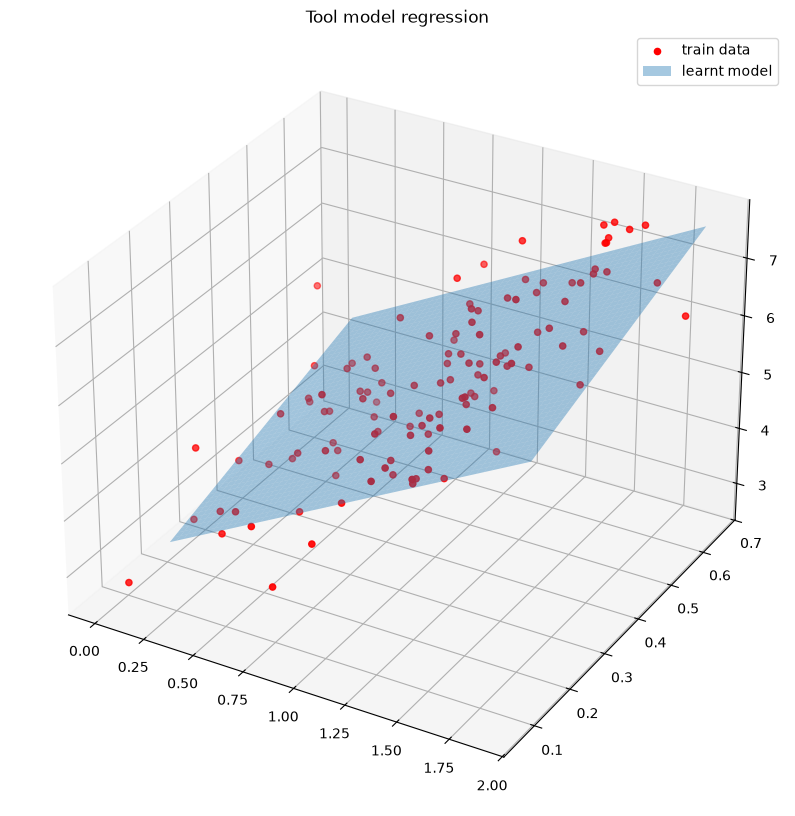

My model error: 
MAE (manual): 3.43
MAE (tool): 3.43
Tool model error: 
MAE (manual): 0.22
MAE (tool): 0.22


In [10]:
# GDP, Freedom - input
# Happiness - output
inputData = [[float(x) for x in gdp], [float(x) for x in freedom]]
outputData = [float(x) for x in happiness]

# Initialize regressor
myRegressor = MySGDRegression()
toolRegressor = SGDRegressor(learning_rate='constant', penalty=None)

# Split data => input: array of arrays, output: array
trainInputs, testInputs, trainOutputs, testOutputs = splitData(inputData, ['GDP', 'Freedom', 'Happiness'], outputData)
# Prepare data for use
trainInputsT = [[f1, f2] for f1,f2 in zip(trainInputs[0], trainInputs[1])]
testInputsT = [[f1, f2] for f1,f2 in zip(testInputs[0], testInputs[1])]

# Prepare data for tool use
toolTrainInputs = np.array(trainInputsT)
toolTestInputs = np.array(testInputsT)
toolTrainOutputs = np.array(trainOutputs)
toolTestOutputs = np.array(testOutputs)

# Train the regressor
epochCount = 1000
myRegressor.fit_batch(trainInputsT, trainOutputs, noEpoch=epochCount)

for _ in range(epochCount):
    toolTrainInputs, toolTrainOutputs = shuffleNP(toolTrainInputs, toolTrainOutputs)
    toolRegressor.partial_fit(toolTrainInputs, toolTrainOutputs)

# Print the model formula
print(f'my learnt model: f(x) = {myRegressor.intercept_:.4f} + {myRegressor.coef_[0]:.4f}  * x1 + {myRegressor.coef_[1]:.4f} * x2')
print(f'tool learnt model: f(x) = {toolRegressor.intercept_.item():.4f} + {toolRegressor.coef_[0]:.4f}  * x + {toolRegressor.coef_[1]:.4f} * x2')

# Plot the model
noOfPoints = 50
x = np.linspace(min(trainInputs[0]) + 0.1, max(trainInputs[0]), noOfPoints)
y = np.linspace(min(trainInputs[1]) + 0.1, max(trainInputs[1]), noOfPoints)
meshX, meshY = np.meshgrid(x, y)
meshZ = myRegressor.intercept_ + myRegressor.coef_[0] * meshX + myRegressor.coef_[1] * meshY
plot3Ddata(trainInputs[0], trainInputs[1], trainOutputs, meshX, meshY, meshZ, None, None, None, 'My model regression')
meshZ = toolRegressor.intercept_ + toolRegressor.coef_[0] * meshX + toolRegressor.coef_[1] * meshY
plot3Ddata(trainInputs[0], trainInputs[1], trainOutputs, meshX, meshY, meshZ, None, None, None, 'Tool model regression')

# Print test data prediction error
myComputedTestOutputs = myRegressor.predict(testInputsT)
toolComputedTestOutputs = toolRegressor.predict(toolTestInputs)
print(f"My model error: ")
error(myComputedTestOutputs, testOutputs)
errorNP(myComputedTestOutputs, testOutputs)
print(f"Tool model error: ")
error(toolComputedTestOutputs, toolTestOutputs)
errorNP(toolComputedTestOutputs, toolTestOutputs)

In [11]:
import math

class MyLogisticRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = []

    # sigmoid is used to normalize a real number to a probability [0, 1]
    @staticmethod
    def _sigmoid(z):
        if z >= 0:
            return 1 / (1 + math.exp(-z))
        else:
            z_exp = math.exp(z)
            return z_exp / (1 + z_exp)

    def eval(self, xi):
        yi = self.intercept_
        for j in range(len(xi)):
            yi += self.coef_[j] * xi[j] # apply linear regression formula
        return self._sigmoid(yi) # return probability using sigmoid

    # X - list of lists (n_samples, n_features)
    def fit(self, X, y, learningRate=0.01, noEpochs=1000):
        self.intercept_ = 0.0
        self.coef_ = [0.0 for _ in range(len(X[0]))]

        for epoch in range(noEpochs):
            gradIntercept = 0.0
            gradCoef = [0.0 for _ in range(len(X[0]))]
            for i in range(len(X)): # iterate over samples
                computedYi = self.eval(X[i]) # compute output for sample i
                error = computedYi - y[i]
                for j in range(len(X[0])):
                    gradCoef[j] += error * X[i][j]
                gradIntercept += error

            for j in range(len(X[0])):
                self.coef_[j] -= learningRate * (gradCoef[j] / len(X))
            self.intercept_ -= learningRate * (gradIntercept / len(X))

    # X - list of lists (n_samples, n_features)
    def predict(self, X, threshold=0.5):
        prob = [self.eval(xi) for xi in X]
        return [1 if p >= threshold else 0 for p in prob]


class MyMulticlassLogisticRegression:
    def __init__(self):
        self.intercept_ = []
        self.coef_ = []
        self.classes_ = []

    @staticmethod
    def _softmax(z):
        max_z = max(z) # Shift for numerical stability
        exp_z = [math.exp(i - max_z) for i in z]
        sum_exp_z = sum(exp_z)
        return [i / sum_exp_z for i in exp_z]

    def eval(self, xi):
        scores = [
            self.intercept_[c] + sum(self.coef_[c][j] * xi[j] for j in range(len(xi)))
            for c in range(len(self.classes_))
        ]
        return self._softmax(scores)

    def fit(self, X, y, learningRate=0.1, noEpochs=1000):
        self.classes_ = sorted(list(set(y)))
        n_classes = len(self.classes_)
        n_features = len(X[0])
        n_samples = len(X)

        self.intercept_ = [0.0] * n_classes
        self.coef_ = [[0.0] * n_features for _ in range(n_classes)]
        y_one_hot = [[1 if y[i] == c else 0 for c in self.classes_] for i in range(n_samples)]

        for _ in range(noEpochs):
            gradIntercept = [0.0] * n_classes
            gradCoef = [[0.0] * n_features for _ in range(n_classes)]

            for i in range(n_samples):
                probs = self.eval(X[i])
                for c in range(n_classes):
                    error = probs[c] - y_one_hot[i][c]
                    gradIntercept[c] += error
                    for j in range(n_features):
                        gradCoef[c][j] += error * X[i][j]

            for c in range(n_classes):
                self.intercept_[c] -= learningRate * (gradIntercept[c] / n_samples)
                for j in range(n_features):
                    self.coef_[c][j] -= learningRate * (gradCoef[c][j] / n_samples)

    def predict(self, X):
        predictions = []
        for xi in X:
            probs = self.eval(xi)
            predictions.append(self.classes_[probs.index(max(probs))])
        return predictions

In [12]:
def manual_brier_score(y_true, y_prob):
    return np.mean((y_prob - y_true)**2)

def manual_zero_one_loss(y_true, y_pred):
    return np.mean(y_true != y_pred)

def manual_log_loss(y_true, y_prob):
    epsilon = 1e-15
    y_prob = np.clip(y_prob, epsilon, 1 - epsilon)
    loss = -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
    return loss

def manual_hinge_loss(y_true, scores):
    # Convert {0, 1} labels to {-1, 1}
    y_transformed = np.where(y_true == 0, -1, 1)
    # loss = max(0, 1 - y * score)
    return np.mean(np.maximum(0, 1 - y_transformed * scores))

# Usage
# print(manual_brier_score(toolTestY, y_prob))

In [13]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)
area = breast_cancer_wisconsin_diagnostic.data.features.area1.values.tolist()
texture = breast_cancer_wisconsin_diagnostic.data.features.texture1.values.tolist()
diagnosis = breast_cancer_wisconsin_diagnostic.data.targets

ModuleNotFoundError: No module named 'ucimlrepo'

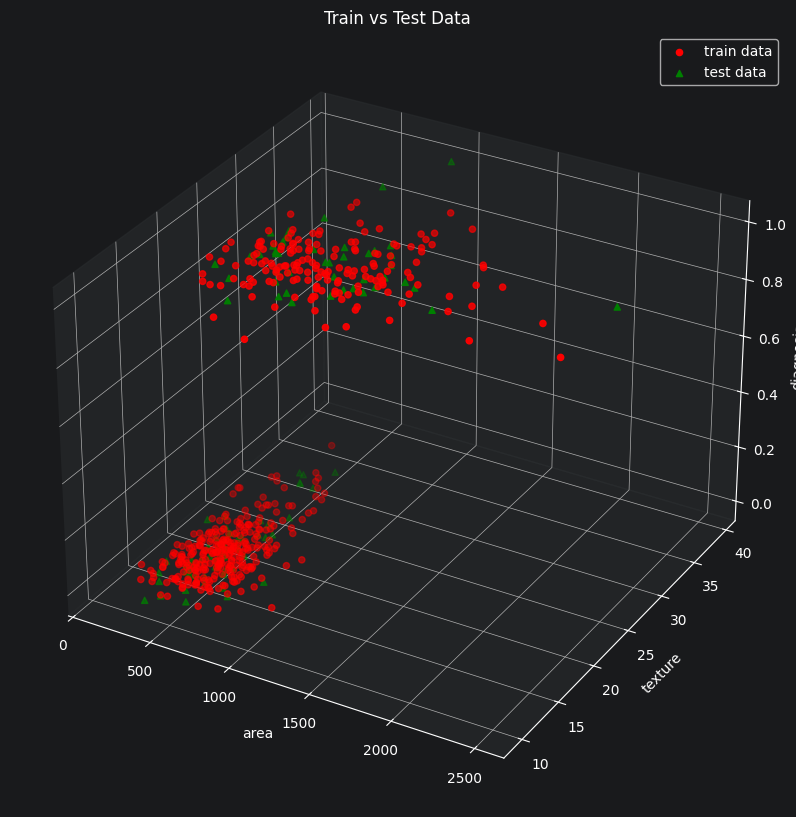

My model: 1.5052 * x1 + 0.6090 * x2 + -0.5109 = 0
Tool model: 3.4600 * x1 + 0.8186 * x2 + -0.4776 = 0


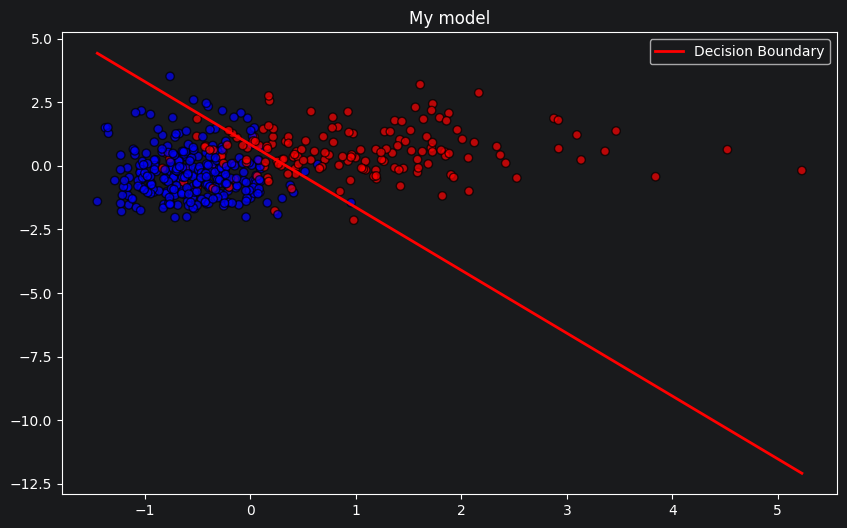

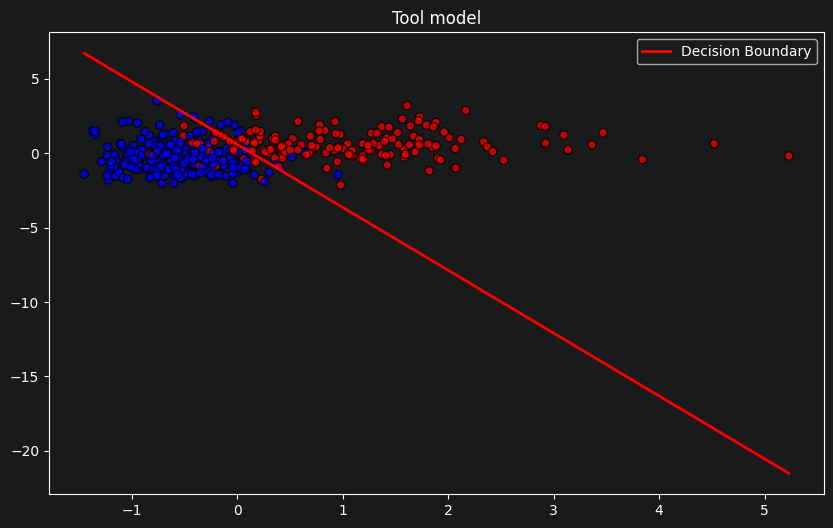

Zero-one loss: 1.0
Brief score: 0.07927140623792116
Log loss: 0.2526284648913879
Hinge score: 0.7737169300345099
Scores per fold: [0.84210526 0.88596491 0.87719298 0.92105263 0.89380531]
Average Accuracy: 0.8840 (+/- 0.0256)
Threshold  | Accuracy   | Precision  | Recall    
----------------------------------------------
0.2        | 0.8684     | 0.7679     | 0.9556    
0.4        | 0.9035     | 0.9048     | 0.8444    
0.5        | 0.8596     | 0.9143     | 0.7111    
0.6        | 0.8596     | 0.9394     | 0.6889    
0.8        | 0.8421     | 1.0000     | 0.6000    
Predictie tool:  [0]
Predictie my classifier:  [0]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score

diagnosisMap = {'M': 1, 'B': 0}
# input - list of lists
# output - list
X = [area, texture]
y = [diagnosisMap[k.item()] for k in diagnosis.values]
# Split data
trainX, testX, trainY, testY = splitData(X, ['area', 'texture', 'diagnosis'], y)

# Normalize data
scaler = MyScaler()
toolScaler = StandardScaler()

# Pre-process data
trainXT = [[t1, t2] for t1,t2 in zip(trainX[0], trainX[1])]
testXT = [[t1, t2] for t1,t2 in zip(testX[0], testX[1])]
trainXT = toolScaler.fit_transform(trainXT)
testXT = toolScaler.transform(testXT)

# Tool data
toolTrainX = np.array(trainXT)
toolTestX = np.array(testXT)
toolTrainY = np.array(trainY)
toolTestY = np.array(testY)

# Train classifier
myClassifier = MyLogisticRegression()
myClassifier.fit(trainXT, trainY)
toolClassifier = LogisticRegression()
toolClassifier.fit(toolTrainX, toolTrainY)

# Print model formula
print(f'My model: {myClassifier.coef_[0]:.4f} * x1 + {myClassifier.coef_[1]:.4f} * x2 + {myClassifier.intercept_:.4f} = 0')
print(f'Tool model: {toolClassifier.coef_[0][0]:.4f} * x1 + {toolClassifier.coef_[0][1]:.4f} * x2 + {toolClassifier.intercept_[0]:.4f} = 0')

# Plot classifier model
noOfPoints = 100
trainX = [[k[0] for k in trainXT], [k[1] for k in trainXT]]
scaledF1 = trainX[0]
scaledF2 = trainX[1]
xRef = np.linspace(min(scaledF1), max(scaledF1), noOfPoints)
yRef = -(myClassifier.coef_[0] / myClassifier.coef_[1]) * xRef - (myClassifier.intercept_ / myClassifier.coef_[1])
plotClassifier(scaledF1, scaledF2, trainY, xRef, yRef,  'My model')
toolScaledF1 = toolTrainX[:, 0]
toolScaledF2 = toolTrainX[:, 1]
xRef = np.linspace(min(toolScaledF1), max(toolScaledF1), noOfPoints)
yRef = -(toolClassifier.coef_[0][0] / toolClassifier.coef_[0][1]) * xRef - (toolClassifier.intercept_[0] / toolClassifier.coef_[0][1])
plotClassifier(toolScaledF1, toolScaledF2, toolTrainY, xRef, yRef, 'Tool model' )

X = np.array([[t1, t2] for t1, t2 in zip(X[0], X[1])])
scaledX = toolScaler.transform(X)
y = np.array(y)

y_probs = toolClassifier.predict_proba(toolTestX)[:, 1]


print(f'Zero-one loss: {manual_zero_one_loss(toolTestY, y_probs)}')
print(f'Brief score: {manual_brier_score(toolTestY, y_probs)}')
print(f'Log loss: {manual_log_loss(toolTestY, y_probs)}')
print(f'Hinge score: {manual_hinge_loss(toolTestY, y_probs)}')

# Cross-validation with 5 folds
# using accuracy scoring ( number of correct queses / total queses )
scores = cross_val_score(toolClassifier, scaledX, y, cv=5, scoring='accuracy')
print(f"Scores per fold: {scores}")
print(f"Average Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")


thresholds = [0.2, 0.4, 0.5, 0.6, 0.8]
print(f"{'Threshold':<10} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10}")
print("-" * 46)

for t in thresholds: # Apply custom threshold

    y_pred_custom = (y_probs >= t).astype(int)

    acc = accuracy_score(toolTestY, y_pred_custom) # (TP + TN) / (FP + FN)
    prec = precision_score(toolTestY, y_pred_custom, zero_division=0) # TP / (TP + FP)
    rec = recall_score(toolTestY, y_pred_custom) # TP / (TP + FN)

    print(f"{t:<10.1f} | {acc:<10.4f} | {prec:<10.4f} | {rec:<10.4f}")

print("Predictie tool: ", toolClassifier.predict(toolScaler.transform([[18, 10]])))
print("Predictie my classifier: ", myClassifier.predict(toolScaler.transform([[18, 10]])))

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
features = iris.data.features.values
X = [features[:, 0].tolist(), features[:, 1].tolist(), features[:, 2].tolist(), features[:, 3].tolist()]
y = [k[0] for k in iris.data.targets.values]

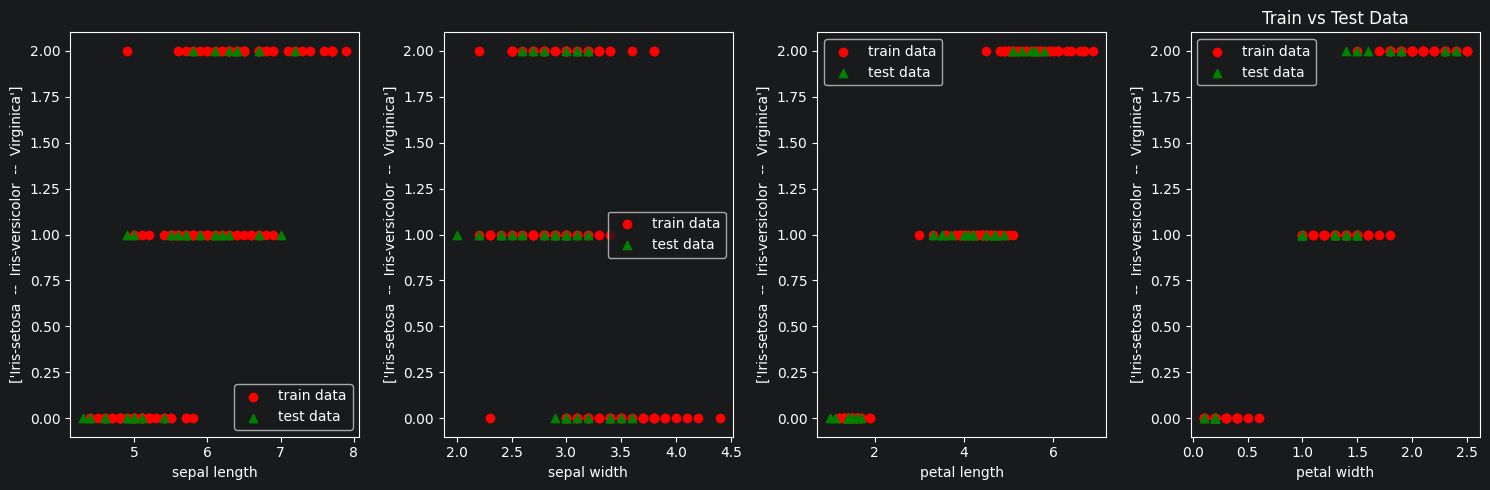

Tool model: 
Iris-setosa: -1.0308 * x1 + 1.1078 * x2 + -1.7889 * x3 + -1.6869 * x4 + -0.2925 = 0
Iris-versicolor: 0.4783 * x1 + -0.2807 * x2 + -0.0487 * x3 + -0.9750 * x4 + 1.8603 = 0
Iris-virginica: 0.5525 * x1 + -0.8271 * x2 + 1.8376 * x3 + 2.6618 * x4 + -1.5678 = 0
My model: 
Iris-setosa: -1.2513 * x1 + 1.3187 * x2 + -2.0797 * x3 + -1.9356 * x4 + -0.5553 = 0
Iris-versicolor: 0.6342 * x1 + -0.3991 * x2 + 0.1250 * x3 + -1.1474 * x4 + 2.0476 = 0
Iris-virginica: 0.6170 * x1 + -0.9196 * x2 + 1.9546 * x3 + 3.0831 * x4 + -1.4922 = 0
tool Accuracy: 0.9333
Accuracy: 0.9333


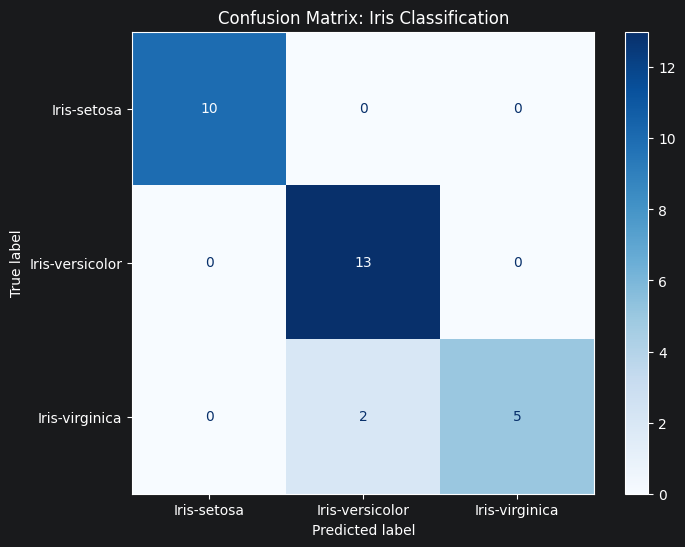

Predictie tool: Iris-setosa
Predicite my classifier: Iris-setosa

Predictie 2: Iris-virginica


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

flowerMap = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
itofMap = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}
inputData = X
outputData = [flowerMap[flower] for flower in y]

# Split data
trainX, testX, trainY, testY = splitData(inputData, [['sepal length', 'sepal width', 'petal length', 'petal width'], ['Iris-setosa  --  Iris-versicolor  --  Virginica']], outputData)
trainXT = [[f1, f2, f3, f4] for f1,f2,f3,f4 in zip(trainX[0], trainX[1], trainX[2], trainX[3])]
testXT = [[f1, f2, f3, f4] for f1,f2,f3,f4 in zip(testX[0], testX[1], testX[2], testX[3])]

# Initialize classifier & scaler
myClassifier = MyMulticlassLogisticRegression()
classifier = LogisticRegression()
scaler = StandardScaler()

# Pre-process data
scaledTrainX = scaler.fit_transform(trainXT)
scaledTestX = scaler.transform(testXT)

classifier.fit(scaledTrainX, trainY)
myClassifier.fit(scaledTrainX.tolist(), trainY)

print('Tool model: ')
classes = list(flowerMap.keys())
for i in range(len(classifier.classes_)):
    coef = classifier.coef_[i]
    intercept = classifier.intercept_[i]
    print(f'{classes[i]}: {coef[0]:.4f} * x1 + {coef[1]:.4f} * x2 + {coef[2]:.4f} * x3 + {coef[3]:.4f} * x4 + {intercept:.4f} = 0')

print('My model: ')
for i in range(len(myClassifier.classes_)):
    coef = myClassifier.coef_[i]
    intercept = myClassifier.intercept_[i]
    print(f'{classes[i]}: {coef[0]:.4f} * x1 + {coef[1]:.4f} * x2 + {coef[2]:.4f} * x3 + {coef[3]:.4f} * x4 + {intercept:.4f} = 0')

# Evaluate model
computedY = classifier.predict(scaledTestX)
print(f'tool Accuracy: {accuracy_score(testY, computedY):.4f}')

computedY = myClassifier.predict(scaledTestX.tolist())
print(f'Accuracy: {accuracy_score(testY, computedY):.4f}')

cm = confusion_matrix(testY, computedY)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

# Plot the matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)

plt.title('Confusion Matrix: Iris Classification')
plt.show()

print(f'Predictie tool: {itofMap[classifier.predict(scaler.transform([[5.35, 3.85, 1.25, 0.4]]))[0]]}')
print(f'Predicite my classifier: {itofMap[myClassifier.predict(scaler.transform([[5.35, 3.85, 1.25, 0.4]]))[0]]}')
print()
print(f'Predictie 2: {itofMap[myClassifier.predict(scaler.transform([[7.12, 3.5, 6.5, 2]]))[0]]}')